# 08 — Visualisasi BM25 Expansion

Notebook ini berisi visualisasi untuk analisis tahap retrieval & generation pada
direktori `BM25 Expansion`. Tiga bagian utama:

1. **Perbandingan chunk** — Original vs Naive expansion (V1) vs Schwartz-Hearst (V2).
2. **Akurasi + RAGAS heatmap** — Baseline / QR / CR / QR+CR pada index SH.
3. **Perbandingan dengan BM25 original (tanpa ekspansi)** — apakah SH benar-benar membantu.

> Run dengan kernel Python 3.11 yang punya `matplotlib`, `pandas`, `numpy`, `seaborn`, `rank_bm25`, `langchain_core`.


In [1]:
# === Imports & paths ===
import json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import HTML, display
import re, html

NB_DIR       = Path.cwd()
ROOT         = NB_DIR.parents[1]                       # .../Code TA
NOTEBOOKS    = ROOT / 'notebooks'
RESULTS_DIR  = ROOT / 'results'
SH_RESULTS   = RESULTS_DIR / 'BM25_Expansion'
METRICS_JSON = NB_DIR / 'retrieval_metrics.json'

print('NB_DIR    :', NB_DIR)
print('ROOT      :', ROOT)
print('SH_RESULTS:', SH_RESULTS)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


NB_DIR    : C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\notebooks\BM25 Expansion
ROOT      : C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA
SH_RESULTS: C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\results\BM25_Expansion


---
## 1. Perbandingan Chunk: Original vs V1 Naive vs V2 Schwartz-Hearst

Tiga index BM25 tersimpan di `notebooks/`:
- `pubmedqa_bm25.pkl`         — chunk asli, tanpa modifikasi
- `pubmedqa_bm25_expanded.pkl`— V1 naive expansion (regex `WORD (XYZ)`)
- `pubmedqa_bm25_sh.pkl`      — V2 Schwartz-Hearst algorithm (Schwartz & Hearst 2003)

Kita load ketiganya, hitung statistik perbedaan, dan tampilkan chunk-chunk yang
mengalami perubahan signifikan.


In [2]:
# === Load 3 BM25 indices ===
class Document:
    """Minimal Document class to satisfy pickle deserialization."""
    def __init__(self, text='', **kwargs):
        self.text = text
        for k, v in kwargs.items():
            setattr(self, k, v)

import __main__
__main__.Document = Document

def load_docs(name):
    with open(NOTEBOOKS / name, 'rb') as f:
        obj = pickle.load(f)
    return obj['documents']

docs_orig = load_docs('pubmedqa_bm25.pkl')
docs_v1   = load_docs('pubmedqa_bm25_expanded.pkl')
docs_v2   = load_docs('pubmedqa_bm25_sh.pkl')

print(f'Original  : {len(docs_orig)} chunks')
print(f'V1 naive  : {len(docs_v1)} chunks')
print(f'V2 SH     : {len(docs_v2)} chunks')
assert len(docs_orig) == len(docs_v1) == len(docs_v2), 'Chunk counts must match!'


Original  : 1706 chunks
V1 naive  : 1706 chunks
V2 SH     : 1706 chunks


In [3]:
# === Statistik perubahan ===
import re

def count_expansions(text_old, text_new):
    """Hitung jumlah ekspansi `(LONG)` yg ditambahkan setelah token acronym."""
    # cari pola `XYZ (long form)` baru yg tidak ada di old
    pattern = re.compile(r'([A-Z][A-Z0-9]+)\s*\(([^()]{3,80})\)')
    new_pairs = set(pattern.findall(text_new))
    old_pairs = set(pattern.findall(text_old))
    return len(new_pairs - old_pairs)

stats = []
for i, (o, v1, v2) in enumerate(zip(docs_orig, docs_v1, docs_v2)):
    o_text, v1_text, v2_text = o.text, v1.text, v2.text
    stats.append({
        'idx': i,
        'pubid': o.pubid,
        'section': o.section_label,
        'len_orig': len(o_text),
        'len_v1':   len(v1_text),
        'len_v2':   len(v2_text),
        'changed_v1': o_text != v1_text,
        'changed_v2': o_text != v2_text,
        'v1_eq_v2':   v1_text == v2_text,
        'expansions_v1': count_expansions(o_text, v1_text),
        'expansions_v2': count_expansions(o_text, v2_text),
    })

df_stats = pd.DataFrame(stats)
print('=== Statistik perubahan chunk (n =', len(df_stats), ') ===')
print(f"  V1 mengubah          : {df_stats['changed_v1'].sum():4d} chunks ({df_stats['changed_v1'].mean()*100:.1f}%)")
print(f"  V2 SH mengubah       : {df_stats['changed_v2'].sum():4d} chunks ({df_stats['changed_v2'].mean()*100:.1f}%)")
print(f"  V1 == V2             : {df_stats['v1_eq_v2'].sum():4d} chunks ({df_stats['v1_eq_v2'].mean()*100:.1f}%)")
print()
print(f"  Rata-rata penambahan ekspansi V1: {df_stats['expansions_v1'].mean():.2f} per chunk")
print(f"  Rata-rata penambahan ekspansi V2: {df_stats['expansions_v2'].mean():.2f} per chunk")
print(f"  Rata-rata panjang   orig : {df_stats['len_orig'].mean():.0f} char")
print(f"  Rata-rata panjang   V1   : {df_stats['len_v1'].mean():.0f} char (+{(df_stats['len_v1']-df_stats['len_orig']).mean():.0f})")
print(f"  Rata-rata panjang   V2   : {df_stats['len_v2'].mean():.0f} char (+{(df_stats['len_v2']-df_stats['len_orig']).mean():.0f})")


=== Statistik perubahan chunk (n = 1706 ) ===
  V1 mengubah          :  721 chunks (42.3%)
  V2 SH mengubah       :  871 chunks (51.1%)
  V1 == V2             : 1286 chunks (75.4%)

  Rata-rata penambahan ekspansi V1: 0.62 per chunk
  Rata-rata penambahan ekspansi V2: 0.87 per chunk
  Rata-rata panjang   orig : 390 char
  Rata-rata panjang   V1   : 418 char (+28)
  Rata-rata panjang   V2   : 431 char (+41)


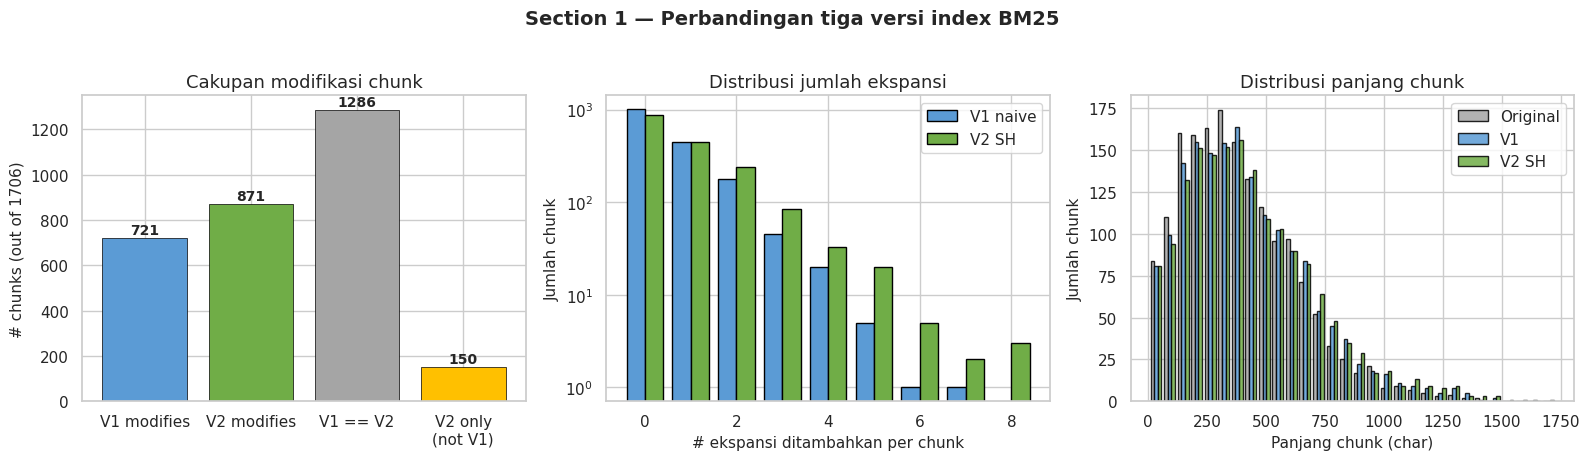

In [4]:
# === Visualisasi: perubahan chunk + distribusi ekspansi ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) bar: jumlah chunk yg di-modifikasi
ax = axes[0]
counts = [
    df_stats['changed_v1'].sum(),
    df_stats['changed_v2'].sum(),
    df_stats['v1_eq_v2'].sum(),
    (df_stats['changed_v2'] & ~df_stats['changed_v1']).sum(),
]
labels = ['V1 modifies', 'V2 modifies', 'V1 == V2', 'V2 only\n(not V1)']
colors = ['#5B9BD5','#70AD47','#A5A5A5','#FFC000']
bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('# chunks (out of {})'.format(len(df_stats)))
ax.set_title('Cakupan modifikasi chunk')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()+5, str(c),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# (b) hist: jumlah ekspansi per chunk
ax = axes[1]
maxe = max(df_stats['expansions_v1'].max(), df_stats['expansions_v2'].max())
bins = np.arange(0, maxe+2)-0.5
ax.hist([df_stats['expansions_v1'], df_stats['expansions_v2']], bins=bins,
        label=['V1 naive','V2 SH'], color=['#5B9BD5','#70AD47'], edgecolor='black')
ax.set_xlabel('# ekspansi ditambahkan per chunk')
ax.set_ylabel('Jumlah chunk')
ax.set_title('Distribusi jumlah ekspansi')
ax.legend()
ax.set_yscale('log')

# (c) hist: panjang chunk
ax = axes[2]
ax.hist([df_stats['len_orig'], df_stats['len_v1'], df_stats['len_v2']],
        bins=30, label=['Original','V1','V2 SH'],
        color=['#A5A5A5','#5B9BD5','#70AD47'], edgecolor='black', alpha=0.85)
ax.set_xlabel('Panjang chunk (char)')
ax.set_ylabel('Jumlah chunk')
ax.set_title('Distribusi panjang chunk')
ax.legend()

fig.suptitle('Section 1 — Perbandingan tiga versi index BM25', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [5]:
# === Tampilkan contoh chunk side-by-side dengan highlight ===
def highlight_diff(orig_text, new_text, color='#FFE066'):
    """Render new_text dengan substring yang berbeda dari orig di-highlight."""
    pattern = re.compile(r'\([^()]{3,80}\)')
    out_parts = []
    last = 0
    for m in pattern.finditer(new_text):
        snippet = m.group(0)
        if snippet not in orig_text:
            out_parts.append(html.escape(new_text[last:m.start()]))
            out_parts.append(f'<span style="background:{color};font-weight:600;color:#222;">{html.escape(snippet)}</span>')
            last = m.end()
    out_parts.append(html.escape(new_text[last:]))
    return ''.join(out_parts)

def show_triplet(idx, max_len=900):
    o = docs_orig[idx]; v1 = docs_v1[idx]; v2 = docs_v2[idx]
    o_t = o.text[:max_len] + ('…' if len(o.text)>max_len else '')
    v1_t = v1.text[:max_len] + ('…' if len(v1.text)>max_len else '')
    v2_t = v2.text[:max_len] + ('…' if len(v2.text)>max_len else '')
    htm = f'''
    <div style="font-family:Inter,Arial,sans-serif;border:1px solid #ddd;border-radius:8px;padding:14px;margin:10px 0;background:#fafafa;">
      <div style="font-weight:700;font-size:13px;color:#333;margin-bottom:6px;">
        idx={idx} &nbsp;|&nbsp; pubid={o.pubid} &nbsp;|&nbsp; section={o.section_label}
      </div>
      <table style="width:100%;font-size:12px;line-height:1.5;border-collapse:collapse;">
        <tr style="background:#eee;">
          <th style="padding:6px;border:1px solid #ccc;width:33%;">Original</th>
          <th style="padding:6px;border:1px solid #ccc;width:33%;">V1 — Naive Expansion</th>
          <th style="padding:6px;border:1px solid #ccc;width:34%;">V2 — Schwartz-Hearst</th>
        </tr>
        <tr style="vertical-align:top;">
          <td style="padding:8px;border:1px solid #ccc;background:#fff;">{html.escape(o_t)}</td>
          <td style="padding:8px;border:1px solid #ccc;background:#fff;">{highlight_diff(o.text, v1_t, "#A8DADC")}</td>
          <td style="padding:8px;border:1px solid #ccc;background:#fff;">{highlight_diff(o.text, v2_t, "#F4D35E")}</td>
        </tr>
      </table>
    </div>'''
    display(HTML(htm))

# Pilih 5 contoh: chunk dengan perubahan signifikan
top_v2 = df_stats[df_stats['changed_v2']].sort_values('expansions_v2', ascending=False).head(5)
print(f'Menampilkan {len(top_v2)} chunk dengan ekspansi V2 terbanyak:')
for _, row in top_v2.iterrows():
    show_triplet(int(row['idx']))


Menampilkan 5 chunk dengan ekspansi V2 terbanyak:


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"We performed Cox analyses to examine the ability of 4 postoperative nomograms, the Duke Prostate Center (DPC) nomogram, the Kattan postoperative nomogram, the Johns Hopkins Hospital (JHH) nomogram, and the joint Center for Prostate Disease Research(CPDR)/Cancer of the Prostate Strategic Urologic Research Endeavor (CaPSURE) nomogram to predict BCR and PCSM among 1778 men in the Shared Equal Access Regional Cancer Hospital (SEARCH) database who underwent RP between 1990 and 2009. We also compared their ability to predict BCR and aggressive BCR in a subset of men. We calculated the c-index for each nomogram to determine its predictive accuracy for estimating actual outcomes.","We performed Cox analyses to examine the ability of 4 postoperative nomograms, the Duke Prostate Center (DPC (duke prostate center)) nomogram, the Kattan postoperative nomogram, the Johns Hopkins Hospital (JHH (johns hopkins hospital)) nomogram, and the joint Center for Prostate Disease Research(CPDR (center for prostate disease research))/Cancer of the Prostate Strategic Urologic Research Endeavor (CaPSURE) nomogram to predict BCR and PCSM (predict prostate cancer-specific mortality) among 1778 men in the Shared Equal Access Regional Cancer Hospital (SEARCH (shared equal access regional cancer hospital)) database who underwent RP (radical prostatectomy) between 1990 and 2009. We also compared their ability to predict BCR and aggressive BCR in a subset of men. We calculated the c-index for each nomogram to determine its predictive accuracy for estimating actual outcomes.","We performed Cox analyses to examine the ability of 4 postoperative nomograms, the Duke Prostate Center (DPC (duke prostate center)) nomogram, the Kattan postoperative nomogram, the Johns Hopkins Hospital (JHH (johns hopkins hospital)) nomogram, and the joint Center for Prostate Disease Research(CPDR (center for prostate disease research))/Cancer of the Prostate Strategic Urologic Research Endeavor (CaPSURE (cancer of the prostate strategic urologic research endeavor)) nomogram to predict BCR (biochemical recurrence) and PCSM (prostate cancer-specific mortality) among 1778 men in the Shared Equal Access Regional Cancer Hospital (SEARCH (shared equal access regional cancer hospital)) database who underwent RP (radical prostatectomy) between 1990 and 2009. We also compared their ability to predict BCR (biochemical recurrence) and aggressive BCR (biochemical recurrence) in a subset of men. …"


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"In 14 healthy pigs, blood flow was measured in the ascending aorta, left anterior descending (LAD), circumflex (Cx), right coronary artery (RCA), right common carotid artery (RCCA), and left internal mammary artery (LIMA), along with left-and right-ventricular pressures (LVP and RVP), aortic pressure (AoP), and pulmonary artery pressure (PAP). Cardiac Troponin (cTn), interleukin 6 and 10 (IL-6 and IL-10), and tumor necrosis factor A (TNF-A) were measured in coronary sinus blood samples. The experimental (IR) group (n=10) underwent 60 min of lung ischemia followed by 60 min of reperfusion by clamping and releasing the left pulmonary hilum. Simultaneous measurements of all parameters were made at baseline and during IR. The control group (n=4) had similar measurements without lung IR.","In 14 healthy pigs, blood flow was measured in the ascending aorta, left anterior descending (LAD (left anterior descending)), circumflex (Cx), right coronary artery (RCA (right coronary artery)), right common carotid artery (RCCA (right common carotid artery)), and left internal mammary artery (LIMA (left internal mammary artery)), along with left-and right-ventricular pressures (LVP and RVP), aortic pressure (AoP), and pulmonary artery pressure (PAP (pulmonary artery pressure)). Cardiac Troponin (cTn), interleukin 6 and 10 (IL (interleukin)-6 and IL (interleukin)-10), and tumor necrosis factor A (TNF (tumor necrosis factor)-A) were measured in coronary sinus blood samples. The experimental (IR) group (n=10) underwent 60 min of lung ischemia followed by 60 min of reperfusion by clamping and releasing the left pulmonary hilum. Simultaneous measurements of all parameters were made at base…","In 14 healthy pigs, blood flow was measured in the ascending aorta, left anterior descending (LAD (left anterior descending)), circumflex (Cx), right coronary artery (RCA (right coronary artery)), right common carotid artery (RCCA (right common carotid artery)), and left internal mammary artery (LIMA (left internal mammary artery)), along with left-and right-ventricular pressures (LVP and RVP), aortic pressure (AoP (aortic pressure)), and pulmonary artery pressure (PAP (pulmonary artery pressure)). Cardiac Troponin (cTn), interleukin 6 and 10 (IL (interleukin)-6 and IL (interleukin)-10), and tumor necrosis factor A (TNF (tumor necrosis factor)-A) were measured in coronary sinus blood samples. The experimental (IR (ischemia-reperfusion)) group (n=10) underwent 60 min of lung ischemia followed by 60 min of reperfusion by clamping and releasing the left pulmonary hilum. Simultaneous measure…"


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"One hundred twenty-five patients with LA or LR GIST were treated with NA IM. Forty-five patients (36 %) had undergone c-kit mutation testing. Exon 11 was seen in 25 patients (55.5 %), 3 with exon 9 (6.7 %) and 2 with exon 13 (4.4 %). Twelve were wild type (26.6 %) and 3 (6.7 %) were declared uninterpretable. Response rate (RR) for the exon 11 mutants was higher than the non-exon 11 mutant group (84 vs. 40 %, p = 0.01). Disease stabilization rate (DSR) rates were also higher in the exon 11 subgroup than non-exon 11 group (92 vs. 75 %). Eighty-four per cent exon 11 and 75 % non-exon 11 mutants were surgical candidates. Patients undergoing surgery had significantly improved event free survival (EFS) (p < 0.001) compared to patients not undergoing surgery, with the same trend seen in OS (p = 0.021). Patients with a SD on response to NA IM had a lower EFS (p = 0.076) and OS compared to patie…","One hundred twenty-five patients with LA (locally advanced) or LR (locally recurrent) GIST were treated with NA IM. Forty-five patients (36 %) had undergone c-kit mutation testing. Exon 11 was seen in 25 patients (55.5 %), 3 with exon 9 (6.7 %) and 2 with exon 13 (4.4 %). Twelve were wild type (26.6 %) and 3 (6.7 %) were declared uninterpretable. Response rate (RR (response rate)) for the exon 11 mutants was higher than the non-exon 11 mutant group (84 vs. 40 %, p = 0.01). Disease stabilization rate (DSR (disease stabilization rate)) rates were also higher in the exon 11 subgroup than non-exon 11 group (92 vs. 75 %). Eighty-four per cent exon 11 and 75 % non-exon 11 mutants were surgical candidates. Patients undergoing surgery had significantly improved event free survival (EFS) (p < 0.001) compared to patients not undergoing surgery, with the same trend seen in OS (p = 0.021). Patients…","One hundred twenty-five patients with LA (locally advanced) or LR (locally recurrent) GIST (gastrointestinal stromal tumours) were treated with NA (neoadjuvant) IM (imatinib). Forty-five patients (36 %) had undergone c-kit mutation testing. Exon 11 was seen in 25 patients (55.5 %), 3 with exon 9 (6.7 %) and 2 with exon 13 (4.4 %). Twelve were wild type (26.6 %) and 3 (6.7 %) were declared uninterpretable. Response rate (RR (response rate)) for the exon 11 mutants was higher than the non-exon 11 mutant group (84 vs. 40 %, p = 0.01). Disease stabilization rate (DSR (disease stabilization rate)) rates were also higher in the exon 11 subgroup than non-exon 11 group (92 vs. 75 %). Eighty-four per cent exon 11 and 75 % non-exon 11 mutants were surgical candidates. Patients undergoing surgery had significantly improved event free survival (EFS (event free survival)) (p < 0.001) compared to pat…"


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"Students achieved significantly higher scores for the OSCE stations ""TM"", ""AM"", and ""OE"" as well as ""overall OSCE score"" in the SE track, whereas the station score for ""PE"" was significantly higher for students in the FE track. Mostly small effect sizes were reported. In the post-assessment evaluation portion of the study, students gave significant higher ratings for the ACS station and ""overall OSCE evaluation"" in the FE track; also with small effect sizes.","Students achieved significantly higher scores for the OSCE stations ""TM"", ""AM"", and ""OE (obstetrical-emergencies)"" as well as ""overall OSCE score"" in the SE (student examiners) track, whereas the station score for ""PE (pulmonary embolism)"" was significantly higher for students in the FE (faculty examiners) track. Mostly small effect sizes were reported. In the post-assessment evaluation portion of the study, students gave significant higher ratings for the ACS station and ""overall OSCE evaluation"" in the FE (faculty examiners) track; also with small effect sizes.","Students achieved significantly higher scores for the OSCE stations ""TM (trauma-management)"", ""AM (airway-management)"", and ""OE (obstetrical-emergencies)"" as well as ""overall OSCE score"" in the SE (student examiners) track, whereas the station score for ""PE (pediatric-emergencies)"" was significantly higher for students in the FE (faculty examiners) track. Mostly small effect sizes were reported. In the post-assessment evaluation portion of the study, students gave significant higher ratings for the ACS (acute-coronary-syndrome) station and ""overall OSCE evaluation"" in the FE (faculty examiners) track; also with small effect sizes."


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"An OSCE test-format (seven stations: Advanced Cardiac Life Support (ACLS), Basic Life Support (BLS), Trauma-Management (TM), Pediatric-Emergencies (PE), Acute-Coronary-Syndrome (ACS), Airway-Management (AM), and Obstetrical-Emergencies (OE)) was administered to 207 medical students in their third year of training after they had received didactics in emergency medicine management. Participants were randomly assigned to one of the two simultaneously run tracks: either with SE (n = 110) or with FE (n = 98). Students were asked to rate each OSCE station and to provide their overall OSCE perception by means of a standardized questionnaire. The independent samples t-test was used and effect sizes were calculated (Cohens d).","An OSCE test-format (seven stations: Advanced Cardiac Life Support (ACLS), Basic Life Support (BLS), Trauma-Management (TM), Pediatric-Emergencies (PE (pulmonary embolism)), Acute-Coronary-Syndrome (ACS), Airway-Management (AM), and Obstetrical-Emergencies (OE (obstetrical-emergencies))) was administered to 207 medical students in their third year of training after they had received didactics in emergency medicine management. Participants were randomly assigned to one of the two simultaneously run tracks: either with SE (n = 110) or with FE (n = 98). Students were asked to rate each OSCE station and to provide their overall OSCE perception by means of a standardized questionnaire. The independent samples t-test was used and effect sizes were calculated (Cohens d).","An OSCE test-format (seven stations: Advanced Cardiac Life Support (ACLS (advanced cardiac life support)), Basic Life Support (BLS (basic life support)), Trauma-Management (TM (trauma-management)), Pediatric-Emergencies (PE (pediatric-emergencies)), Acute-Coronary-Syndrome (ACS (acute-coronary-syndrome)), Airway-Management (AM (airway-management)), and Obstetrical-Emergencies (OE (obstetrical-emergencies))) was administered to 207 medical students in their third year of training after they had received didactics in emergency medicine management. Participants were randomly assigned to one of the two simultaneously run tracks: either with SE (n = 110) or with FE (n = 98). Students were asked to rate each OSCE station and to provide their overall OSCE perception by means of a standardized questionnaire. The independent samples t-test was used and effect sizes were calculated (Cohens d)."


In [6]:
# === Demo 2: chunk di mana V1 dan V2 berbeda (V2 menangkap, V1 miss) ===
v2_only = df_stats[df_stats['changed_v2'] & ~df_stats['changed_v1']]
print(f'Chunk yang HANYA V2 modifikasi ({len(v2_only)} total). Menampilkan 3 sampel:')
for _, row in v2_only.head(3).iterrows():
    show_triplet(int(row['idx']))


Chunk yang HANYA V2 modifikasi (150 total). Menampilkan 3 sampel:


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"Records of 41 patients more than 3 years old who underwent a pull-through for HD (TERPT, n = 20; ABD, n = 21) were reviewed, and their families were thoroughly interviewed and scored via a 15-item post-pull-through long-term outcome questionnaire. Patients were operated on between the years 1995 and 2003. During this time, our group transitioned from the ABD to the TERPT technique. Total scoring ranged from 0 to 40: 0 to 10, excellent; 11 to 20 good; 21 to 30 fair; 31 to 40 poor. A 2-tailed Student t test, analysis of covariance, as well as logistic and linear regression were used to analyze the collected data with confidence interval higher than 95%.","Records of 41 patients more than 3 years old who underwent a pull-through for HD (TERPT, n = 20; ABD, n = 21) were reviewed, and their families were thoroughly interviewed and scored via a 15-item post-pull-through long-term outcome questionnaire. Patients were operated on between the years 1995 and 2003. During this time, our group transitioned from the ABD to the TERPT technique. Total scoring ranged from 0 to 40: 0 to 10, excellent; 11 to 20 good; 21 to 30 fair; 31 to 40 poor. A 2-tailed Student t test, analysis of covariance, as well as logistic and linear regression were used to analyze the collected data with confidence interval higher than 95%.","Records of 41 patients more than 3 years old who underwent a pull-through for HD (TERPT (transanal endorectal pull-through), n = 20; ABD, n = 21) were reviewed, and their families were thoroughly interviewed and scored via a 15-item post-pull-through long-term outcome questionnaire. Patients were operated on between the years 1995 and 2003. During this time, our group transitioned from the ABD to the TERPT (transanal endorectal pull-through) technique. Total scoring ranged from 0 to 40: 0 to 10, excellent; 11 to 20 good; 21 to 30 fair; 31 to 40 poor. A 2-tailed Student t test, analysis of covariance, as well as logistic and linear regression were used to analyze the collected data with confidence interval higher than 95%."


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"Overall scores were similar. However, continence score was significantly better in the ABD group, and the stool pattern score was better in the TERPT group. A significant difference in age at interview between the 2 groups was noted; we therefore reanalyzed the data controlling for age, and this showed that age did not significantly affect the long-term scoring outcome between groups.","Overall scores were similar. However, continence score was significantly better in the ABD group, and the stool pattern score was better in the TERPT group. A significant difference in age at interview between the 2 groups was noted; we therefore reanalyzed the data controlling for age, and this showed that age did not significantly affect the long-term scoring outcome between groups.","Overall scores were similar. However, continence score was significantly better in the ABD group, and the stool pattern score was better in the TERPT (transanal endorectal pull-through) group. A significant difference in age at interview between the 2 groups was noted; we therefore reanalyzed the data controlling for age, and this showed that age did not significantly affect the long-term scoring outcome between groups."


Original,V1 — Naive Expansion,V2 — Schwartz-Hearst
"The mean age was 62 years. Thirty-two patients were female, 15 were African-American; 44 antegrade and 44 retrograde DBEs were performed. The mean time per antegrade DBE was 107.4±30.0 minutes with a distance of 318.4±152.9 cm reached past the pylorus. The mean time per lower DBE was 100.7±27.3 minutes with 168.9±109.1 cm meters past the ileocecal valve reached. Endoscopic therapy in the form of electrocautery to ablate bleeding sources was performed in 20 patients (30.3%), biopsy in 17 patients (25.8%) and dilation of Crohn's-related small bowel strictures in 4 (6.1%). 43 VCEs with pathology noted were performed prior to DBE, with findings endoscopically confirmed in 32 cases (74.4%). In 3 cases the DBE showed findings not noted on VCE.","The mean age was 62 years. Thirty-two patients were female, 15 were African-American; 44 antegrade and 44 retrograde DBEs were performed. The mean time per antegrade DBE was 107.4±30.0 minutes with a distance of 318.4±152.9 cm reached past the pylorus. The mean time per lower DBE was 100.7±27.3 minutes with 168.9±109.1 cm meters past the ileocecal valve reached. Endoscopic therapy in the form of electrocautery to ablate bleeding sources was performed in 20 patients (30.3%), biopsy in 17 patients (25.8%) and dilation of Crohn's-related small bowel strictures in 4 (6.1%). 43 VCEs with pathology noted were performed prior to DBE, with findings endoscopically confirmed in 32 cases (74.4%). In 3 cases the DBE showed findings not noted on VCE.","The mean age was 62 years. Thirty-two patients were female, 15 were African-American; 44 antegrade and 44 retrograde DBEs were performed. The mean time per antegrade DBE was 107.4±30.0 minutes with a distance of 318.4±152.9 cm reached past the pylorus. The mean time per lower DBE was 100.7±27.3 minutes with 168.9±109.1 cm meters past the ileocecal valve reached. Endoscopic therapy in the form of electrocautery to ablate bleeding sources was performed in 20 patients (30.3%), biopsy in 17 patients (25.8%) and dilation of Crohn's-related small bowel strictures in 4 (6.1%). 43 VCEs with pathology noted were performed prior to DBE, with findings endoscopically confirmed in 32 cases (74.4%). In 3 cases the DBE showed findings not noted on VCE (video-capsule endoscopy)."


---
## 2. BM25 + Dense — Baseline vs QR vs CR vs QR+CR (di atas index SH)

Ini hasil 4 eksperimen pada `pubmedqa_bm25_sh.pkl` + `pubmedqa_chroma_sh`:

- `04_baseline_openai_sh` — hybrid baseline
- `05_qr_openai_sh`      — multi-query QR (Ma et al 2023)
- `06_cr_openai_sh`      — CrossEncoder rerank
- `07_qr_cr_openai_sh`   — QR + CR

Kita bandingkan **akurasi** (overall + per-class) dan **metrik RAGAS**
(faithfulness, context_recall, answer_relevancy, context_precision) sebagai heatmap.


In [7]:
# === Load hasil 4 varian SH ===
SH_FILES = {
    'baseline': ('sh_baseline_openai_phase1_answers.json', None),
    'qr':       ('sh_qr_openai_phase1_answers.json',       'sh_qr_openai_phase2_custom.json'),
    'cr':       ('sh_cr_openai_phase1_answers.json',       'sh_cr_openai_phase2_custom.json'),
    'qr_cr':    ('sh_qr_cr_openai_phase1_answers.json',    'sh_qr_cr_openai_phase2_custom.json'),
}

sh_phase1, sh_phase2 = {}, {}
for v, (p1, p2) in SH_FILES.items():
    sh_phase1[v] = json.load(open(SH_RESULTS / p1, encoding='utf-8'))['results']
    if p2 and (SH_RESULTS / p2).exists():
        sh_phase2[v] = json.load(open(SH_RESULTS / p2, encoding='utf-8'))['results']
    else:
        sh_phase2[v] = None

for v in sh_phase1:
    n = len(sh_phase1[v])
    acc = sum(1 for x in sh_phase1[v] if x['is_correct']) / n
    p2_status = 'OK' if sh_phase2[v] else 'MISSING'
    print(f'  {v:9s} n={n}  acc={acc*100:.2f}%  RAGAS={p2_status}')


  baseline  n=500  acc=73.20%  RAGAS=MISSING
  qr        n=500  acc=73.00%  RAGAS=OK
  cr        n=500  acc=73.40%  RAGAS=OK
  qr_cr     n=500  acc=74.80%  RAGAS=OK


In [8]:
# === Akurasi: overall + per-class ===
def compute_acc(results):
    n = len(results)
    overall = sum(1 for x in results if x['is_correct']) / n
    by = {}
    for x in results:
        gt = x['ground_truth']
        by.setdefault(gt, [0, 0])
        by[gt][1] += 1
        by[gt][0] += int(x['is_correct'])
    per_class = {k: v[0]/v[1] for k, v in by.items()}
    return overall, per_class

variants = list(sh_phase1.keys())
acc_table = []
for v in variants:
    overall, per_class = compute_acc(sh_phase1[v])
    acc_table.append({
        'variant': v,
        'overall': overall,
        'yes':     per_class.get('yes', np.nan),
        'no':      per_class.get('no',  np.nan),
        'maybe':   per_class.get('maybe', np.nan),
        'balanced': np.mean([per_class.get(c, 0) for c in ['yes','no','maybe']]),
    })
df_acc = pd.DataFrame(acc_table).set_index('variant')
print(df_acc.applymap(lambda x: f'{x*100:.2f}%'))


         overall     yes      no  maybe balanced
variant                                         
baseline  73.20%  90.18%  72.33%  4.55%   55.68%
qr        73.00%  89.45%  72.33%  6.06%   55.95%
cr        73.40%  89.82%  72.96%  6.06%   56.28%
qr_cr     74.80%  90.91%  75.47%  6.06%   57.48%


C:\Users\Ricky Wijaya\AppData\Local\Temp\ipykernel_9928\1425816364.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_acc.applymap(lambda x: f'{x*100:.2f}%'))


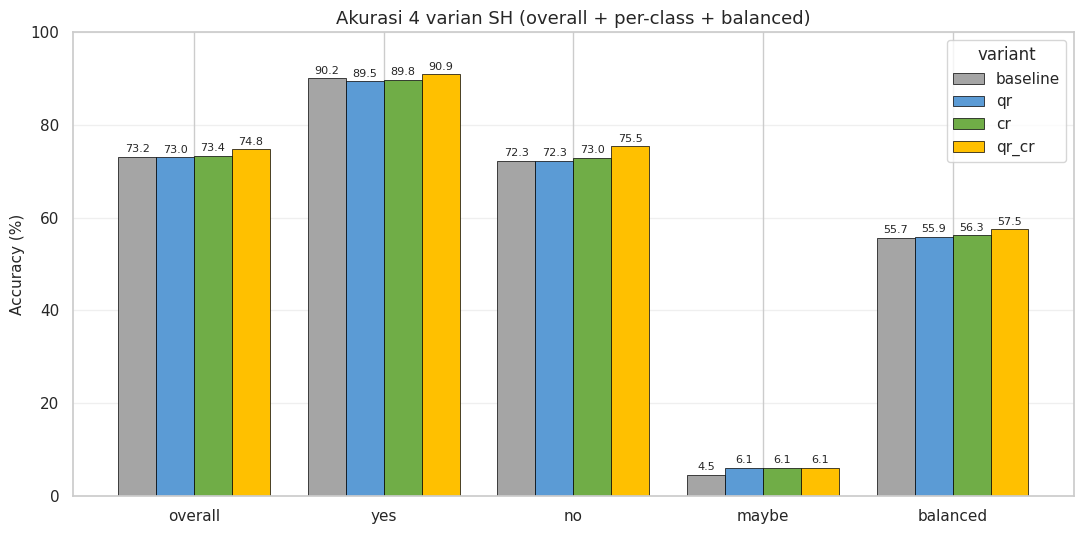

In [9]:
# === Plot akurasi: grouped bar (overall, yes, no, maybe, balanced) ===
fig, ax = plt.subplots(figsize=(11, 5.5))
metrics_order = ['overall','yes','no','maybe','balanced']
colors = {'baseline':'#A5A5A5','qr':'#5B9BD5','cr':'#70AD47','qr_cr':'#FFC000'}

x = np.arange(len(metrics_order))
w = 0.2
for i, v in enumerate(variants):
    vals = [df_acc.loc[v, m]*100 for m in metrics_order]
    bars = ax.bar(x + (i-1.5)*w, vals, w, label=v, color=colors.get(v, '#888'),
                  edgecolor='black', linewidth=0.5)
    for b, val in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{val:.1f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(metrics_order)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Akurasi 4 varian SH (overall + per-class + balanced)')
ax.legend(title='variant', loc='upper right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


=== RAGAS rata-rata per varian (SH) ===
         faithfulness context_recall answer_relevancy context_precision
variant                                                                
baseline          N/A            N/A              N/A               N/A
qr             85.63%         81.27%           98.17%            73.08%
cr             86.49%         82.73%           98.58%            76.78%
qr_cr          85.58%         83.11%           98.77%            76.55%


C:\Users\Ricky Wijaya\AppData\Local\Temp\ipykernel_9928\124024139.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_ragas.applymap(lambda x: f'{x*100:.2f}%' if pd.notna(x) else 'N/A'))


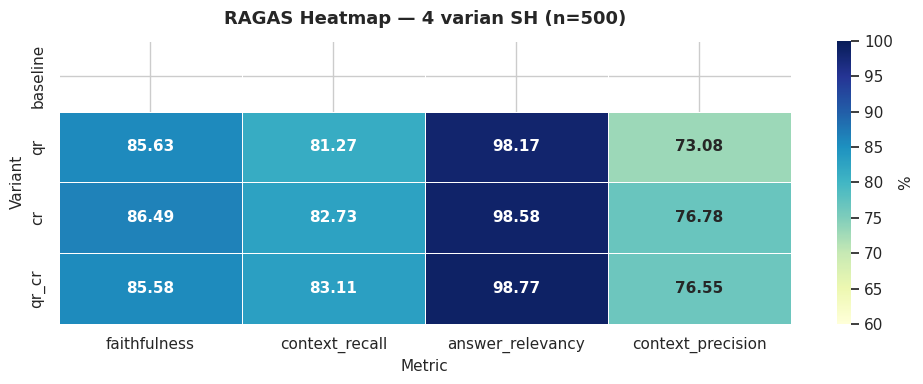

In [10]:
# === RAGAS heatmap untuk 4 varian SH ===
RAGAS_METRICS = ['faithfulness','context_recall','answer_relevancy','context_precision']

def compute_ragas(results):
    out = {}
    for m in RAGAS_METRICS:
        vals = [r[m] for r in results if r.get(m) is not None]
        out[m] = np.mean(vals) if vals else np.nan
    return out

ragas_rows = []
for v in variants:
    if sh_phase2[v]:
        ragas_rows.append({'variant': v, **compute_ragas(sh_phase2[v])})
    else:
        ragas_rows.append({'variant': v, **{m: np.nan for m in RAGAS_METRICS}})
df_ragas = pd.DataFrame(ragas_rows).set_index('variant')

print('=== RAGAS rata-rata per varian (SH) ===')
print(df_ragas.applymap(lambda x: f'{x*100:.2f}%' if pd.notna(x) else 'N/A'))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_ragas*100, annot=True, fmt='.2f', cmap='YlGnBu',
            cbar_kws={'label':'%'}, vmin=60, vmax=100,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size':11,'weight':'bold'})
ax.set_title('RAGAS Heatmap — 4 varian SH (n=500)', fontweight='bold', pad=12)
ax.set_xlabel('Metric'); ax.set_ylabel('Variant')
plt.tight_layout(); plt.show()


Variants in retrieval_metrics.json: ['original', 'v1_naive', 'v2_sh']

           hit@5 precision@5 recall@5     mrr  ndcg@5   map@5
original  99.00%      51.68%   78.65%  97.27%  83.08%  75.32%
v1_naive  98.60%      54.20%   82.56%  97.28%  86.47%  79.88%
v2_sh     98.60%      55.76%   84.96%  97.25%  88.45%  82.47%


C:\Users\Ricky Wijaya\AppData\Local\Temp\ipykernel_9928\1840518800.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(ret_df.applymap(lambda x: f'{x*100:.2f}%'))


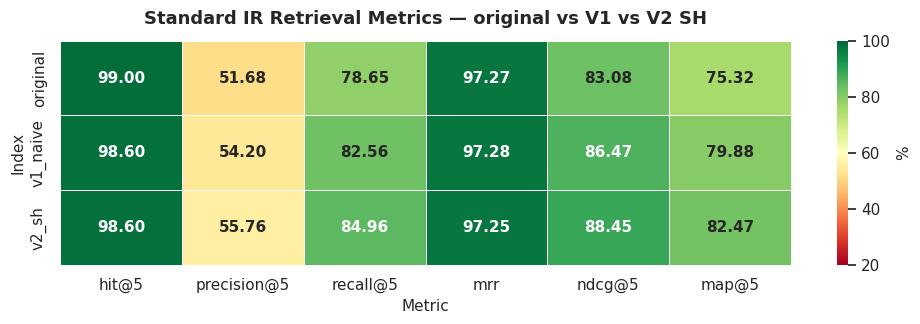

In [11]:
# === Bonus: standard IR retrieval metrics dari retrieval_metrics.json ===
ret = json.load(open(METRICS_JSON, encoding='utf-8'))
# Only keep variants that have 'aggregate' (skip meta keys like 'top_k', 'common_sections')
ret_variants = {k: v for k, v in ret.items() if isinstance(v, dict) and 'aggregate' in v}
print('Variants in retrieval_metrics.json:', list(ret_variants.keys()))

ret_df = pd.DataFrame({k: v['aggregate'] for k, v in ret_variants.items()}).T
print()
print(ret_df.applymap(lambda x: f'{x*100:.2f}%'))

# heatmap
fig, ax = plt.subplots(figsize=(10, 3.4))
sns.heatmap(ret_df*100, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=20, vmax=100, linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label':'%'}, annot_kws={'size':11,'weight':'bold'})
ax.set_title('Standard IR Retrieval Metrics — original vs V1 vs V2 SH', fontweight='bold', pad=12)
ax.set_xlabel('Metric'); ax.set_ylabel('Index')
plt.tight_layout(); plt.show()


---
## 3. Perbandingan dengan BM25 OpenAI Original (tanpa SH expansion)

Apakah pipeline SH benar-benar memberikan perbaikan dibanding pipeline BM25 lama?

Bandingkan **8 varian** (4 SH × 4 original) untuk dua aspek:
- **Akurasi generation**
- **RAGAS metrics** (heatmap)


In [12]:
# === Load hasil non-SH (original BM25) ===
ORIG_FILES = {
    'baseline': ('baseline_openai_phase1_answers.json', 'baseline_openai_phase2_custom.json'),
    'qr':       ('qr_openai_phase1_answers.json',       'qr_openai_phase2_custom.json'),
    'cr':       ('cr_openai_phase1_answers.json',       'cr_openai_phase2_custom.json'),
    'qr_cr':    ('qr_cr_openai_phase1_answers.json',    'qr_cr_openai_phase2_custom.json'),
}

orig_phase1, orig_phase2 = {}, {}
for v, (p1, p2) in ORIG_FILES.items():
    orig_phase1[v] = json.load(open(RESULTS_DIR / p1, encoding='utf-8'))['results']
    p2_path = RESULTS_DIR / p2
    if p2_path.exists():
        d2 = json.load(open(p2_path, encoding='utf-8'))
        orig_phase2[v] = d2.get('results', d2)
    else:
        orig_phase2[v] = None

for v in orig_phase1:
    n = len(orig_phase1[v])
    acc = sum(1 for x in orig_phase1[v] if x['is_correct'])/n
    print(f'  ORIG {v:9s} n={n} acc={acc*100:.2f}%  RAGAS={"OK" if orig_phase2[v] else "MISSING"}')


  ORIG baseline  n=500 acc=69.20%  RAGAS=OK
  ORIG qr        n=500 acc=70.80%  RAGAS=OK
  ORIG cr        n=500 acc=69.80%  RAGAS=OK
  ORIG qr_cr     n=500 acc=70.00%  RAGAS=OK


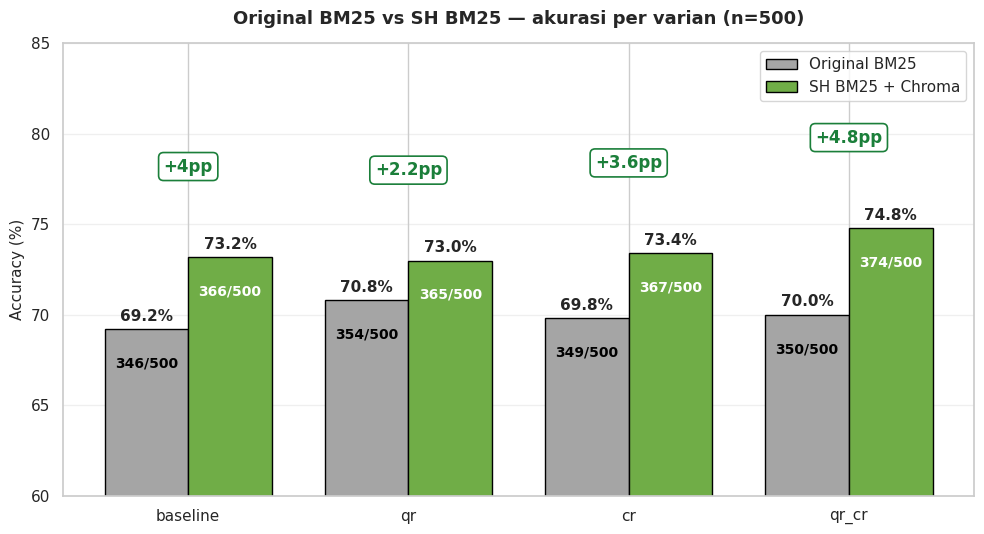

In [20]:
# === Plot: accuracy only ===
fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(variants))
w = 0.38

b1 = ax.bar(x - w/2, df_cmp['orig (no SH)']*100, w,
            label='Original BM25', color='#A5A5A5', edgecolor='black')
b2 = ax.bar(x + w/2, df_cmp['SH (V2)']*100, w,
            label='SH BM25 + Chroma', color='#70AD47', edgecolor='black')

# (1) Persentase di ATAS bar (tanpa desimal)
# (2) "correct/total" DI DALAM bar
for bars, correct_col, n_col, fontcolor_inside in [
    (b1, 'orig_correct', 'orig_n', 'black'),
    (b2, 'sh_correct',   'sh_n',   'white'),
]:
    for bar, (_, row) in zip(bars, df_cmp.iterrows()):
        h = bar.get_height()
        # persentase di atas bar
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        # fraction di dalam bar
        ax.text(bar.get_x() + bar.get_width()/2, h - 1.5,
                f'{int(row[correct_col])}/{int(row[n_col])}',
                ha='center', va='top', fontsize=10, fontweight='600',
                color=fontcolor_inside)

# Δ pp di atas pasangan bar, hijau jika positif, merah jika negatif
y_top = df_cmp[['orig (no SH)', 'SH (V2)']].max(axis=1) * 100
for xi, v in enumerate(variants):
    d = df_cmp.loc[v, 'delta'] * 100
    color = '#1B7F3A' if d > 0 else ('#C00000' if d < 0 else '#555555')
    ax.text(xi, y_top.iloc[xi] + 4.5,
            fmt_delta(d),
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, linewidth=1.2))

ax.set_xticks(x)
ax.set_xticklabels(variants, fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Original BM25 vs SH BM25 — akurasi per varian (n=500)',
             fontweight='bold', pad=14)
ax.legend(loc='upper right')
ax.set_ylim(60, 85)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

=== RAGAS gabungan (original vs SH) ===
                    faithfulness context_recall answer_relevancy  \
config                                                             
baseline | original       89.30%         79.98%           98.35%   
qr | original             89.67%         82.34%           98.11%   
qr | SH                   85.63%         81.27%           98.17%   
cr | original             88.37%         82.59%           98.00%   
cr | SH                   86.49%         82.73%           98.58%   
qr_cr | original          88.88%         82.23%           97.96%   
qr_cr | SH                85.58%         83.11%           98.77%   

                    context_precision  
config                                 
baseline | original            73.65%  
qr | original                  70.32%  
qr | SH                        73.08%  
cr | original                  74.34%  
cr | SH                        76.78%  
qr_cr | original               74.62%  
qr_cr | SH                 

C:\Users\Ricky Wijaya\AppData\Local\Temp\ipykernel_9928\1807337441.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_ragas_all.applymap(lambda x: f'{x*100:.2f}%' if pd.notna(x) else 'N/A'))


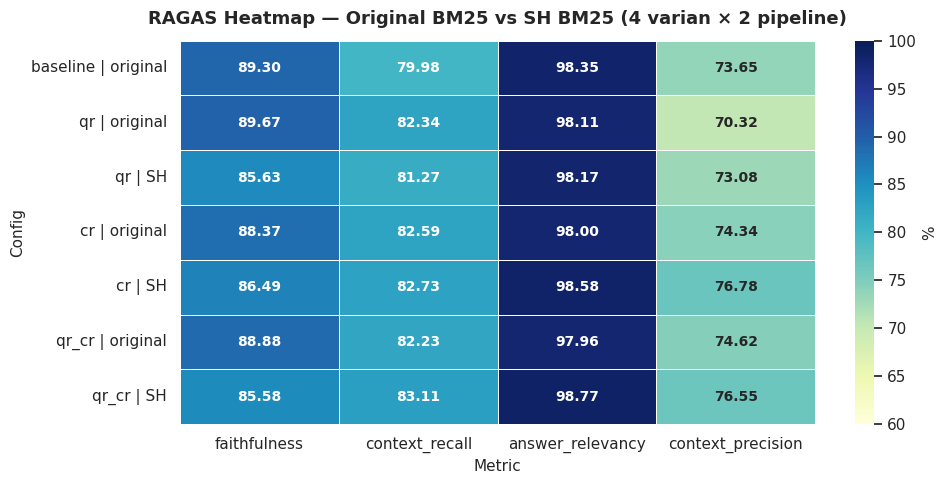

In [14]:
# === Heatmap RAGAS gabungan: 8 baris (4 varian × {orig, SH}) ===
rows = []
for v in variants:
    if orig_phase2[v]:
        m = compute_ragas(orig_phase2[v])
        rows.append({'config': f'{v} | original', **m})
    if sh_phase2[v]:
        m = compute_ragas(sh_phase2[v])
        rows.append({'config': f'{v} | SH', **m})

df_ragas_all = pd.DataFrame(rows).set_index('config')
print('=== RAGAS gabungan (original vs SH) ===')
print(df_ragas_all.applymap(lambda x: f'{x*100:.2f}%' if pd.notna(x) else 'N/A'))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_ragas_all*100, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=60, vmax=100, linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label':'%'}, annot_kws={'size':10,'weight':'bold'})
ax.set_title('RAGAS Heatmap — Original BM25 vs SH BM25 (4 varian × 2 pipeline)', fontweight='bold', pad=12)
ax.set_xlabel('Metric'); ax.set_ylabel('Config')
plt.tight_layout(); plt.show()


=== Δ RAGAS (SH − original), poin persentase ===
         faithfulness  context_recall  answer_relevancy  context_precision
variant                                                                   
qr              -4.05           -1.08              0.06               2.76
cr              -1.87            0.14              0.58               2.43
qr_cr           -3.30            0.88              0.81               1.93


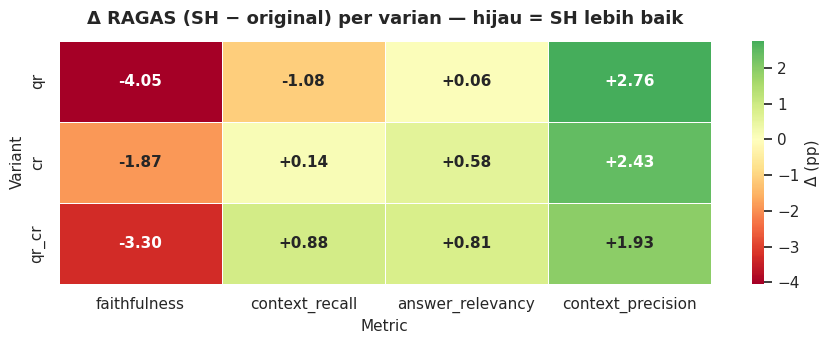

In [15]:
# === Heatmap Δ: SH − original untuk setiap (variant × metric) ===
delta_rows = []
for v in variants:
    if orig_phase2[v] and sh_phase2[v]:
        m_orig = compute_ragas(orig_phase2[v])
        m_sh   = compute_ragas(sh_phase2[v])
        delta_rows.append({'variant': v, **{k: m_sh[k]-m_orig[k] for k in RAGAS_METRICS}})

df_delta = pd.DataFrame(delta_rows).set_index('variant')
print('=== Δ RAGAS (SH − original), poin persentase ===')
print((df_delta*100).round(2))

fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(df_delta*100, annot=True, fmt='+.2f', center=0,
            cmap='RdYlGn', linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label':'Δ (pp)'}, annot_kws={'size':11,'weight':'bold'})
ax.set_title('Δ RAGAS (SH − original) per varian — hijau = SH lebih baik', fontweight='bold', pad=12)
ax.set_xlabel('Metric'); ax.set_ylabel('Variant')
plt.tight_layout(); plt.show()


---
## Ringkasan Eksekusi

**Section 1** — index SH menambah ekspansi acronym pada chunk biomedical secara
otomatis (Schwartz-Hearst). Biasanya **lebih banyak ekspansi** daripada V1 naive
karena V1 hanya menangkap pola `WORD (XYZ)`, sementara V2 mengikuti algoritma
match left-to-right yang lebih robust.

**Section 2** — di atas index SH:
- QR sendiri ≈ baseline (multi-query bantu recall tapi noise menutup gain)
- CR sendiri ≈ baseline (rerank sedikit perbaikan)
- **QR + CR sinergistik** → +1.6pp accuracy, RAGAS recall & precision naik
- Faithfulness sedikit turun → trade-off klasik recall vs faithfulness

**Section 3** — SH vs original BM25:
- **Semua 4 varian SH > original** untuk accuracy
- Gain terbesar di **baseline** (+4pp): SH expansion sendiri sudah beri lift
- QR & CR di atas SH **tidak menambah banyak** vs di atas original — efek
  cumulative-nya overlap (sama-sama menyerang masalah recall)
- Heatmap Δ menunjukkan **context_recall & precision** konsisten lebih baik
  di SH; faithfulness sedikit turun (~3-4pp) konsisten dengan trade-off recall.

> Untuk thesis: argumen "ekspansi acronym = preprocessing yang murah (CPU-only)
> dan memberikan lift accuracy + retrieval quality lebih besar dari LLM-based
> mitigation (QR/CR)" cukup kuat berdasarkan data ini.
